In [ ]:
from datasets import load_dataset
import json
import os
# from huggingface_hub import notebook_login

# Authenticate with the Hugging Face Hub (will prompt for your token)
# notebook_login()
hf_token = "YOUR_HF_TOKEN_HERE"
os.environ["HF_TOKEN"] = hf_token

# load the gated dataset (requires authentication)
# ds = load_dataset("Idavidrein/gpqa", "gpqa_diamond", trust_remote_code=True)
ds = load_dataset("fingertap/GPQA-Diamond")

/home/junseokkim00/.conda/envs/ahaSafe/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-3B-Instruct", trust_remote_code=True)

In [3]:
# ds['train'][0]
question_length = []
cnt=0
for idx, item in enumerate(ds['test']):
    if idx == 71:
        continue
    length = len(tokenizer.encode(item['question'], add_special_tokens=False))
    cnt+= len(item['question'])
    question_length.append(length)
cnt / (len(ds['test'])-1)
# print(ds['test'][71]['question'])

598.1269035532995

In [4]:
import json

with open("../math500/test.jsonl", "r") as f:
    data = [json.loads(line) for line in f]

In [6]:
cnt=0
for inst in data:
    cnt+=len(inst['problem'])
cnt / len(data)

195.892

In [7]:
ds = load_dataset("openai/gsm8k", "main")

In [13]:
cnt=0
for inst in ds['test']:
    # cnt+=len(tokenizer.encode(inst['question'], add_special_tokens=False))
    cnt+=len(inst['question'])
cnt / len(ds['test'])

239.87111448066716

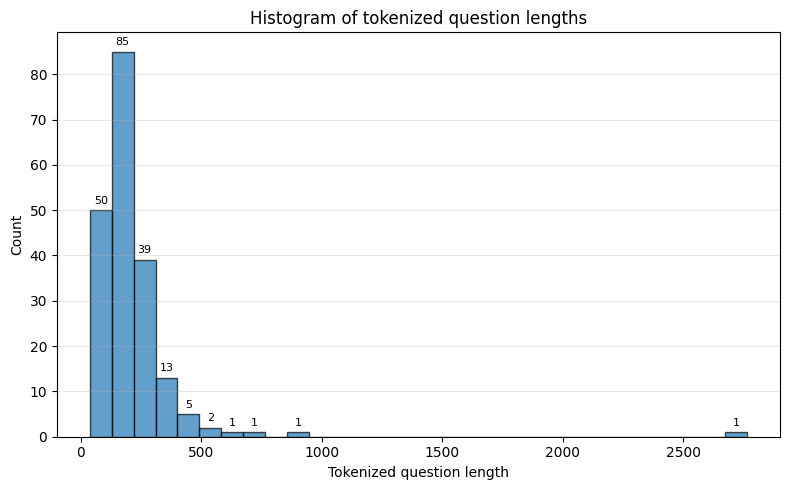

In [7]:
import numpy as np
import matplotlib.pyplot as plt

q = np.array(question_length)

plt.figure(figsize=(8,5))
n, bins, patches = plt.hist(q, bins=30, color='C0', edgecolor='k', alpha=0.7)
plt.xlabel('Tokenized question length')
plt.ylabel('Count')
plt.title('Histogram of tokenized question lengths')
plt.grid(axis='y', alpha=0.3)

# add count labels above each bar
for p, count in zip(patches, n):
    if count > 0:
        x = p.get_x() + p.get_width() / 2
        plt.text(x, count + 1, str(int(count)), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()